In [1]:
# Install/upgrade the SDK quietly (does nothing if already present)
# %pip -q install --upgrade openai

import os, pathlib, pandas as pd, json, textwrap
from openai import OpenAI
import matplotlib.pyplot as plt
import openai
from openai import OpenAI
import numpy as np
from tqdm import tqdm


# -------------------------------------------------------------------
# Locate API key: env var ➜ key/openai_key.txt
# -------------------------------------------------------------------
key_path = pathlib.Path("key/openai_key.txt")

if os.getenv("OPENAI_API_KEY") is None and key_path.exists():
    os.environ["OPENAI_API_KEY"] = key_path.read_text().strip()

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(
        "No API key found.\n"
        "Create key/openai_key.txt (single line) or export OPENAI_API_KEY in your shell."
    )

client = OpenAI()  # SDK reads the key from the env var

In [63]:
# data contains the all papers from the JoF and the top 5 journals except jpe that contain the word stock returns or synonyms in the title
# the sampling period is 20 years (7300 days)
df = pd.read_csv(r"C:\Users\jonat\Lasso_paper\openalex_abstracts_out\abstracts.csv")

# delete all rows without an abstract - mostly not papers
df = df.dropna(subset=["abstract"])

# rename idx to paper_id
df = df.rename(columns={"idx": "paper_id"})

In [65]:
len(df)

5637

In [64]:
response_format_batch = {
    "type": "json_schema",
    "json_schema": {
        "name": "batched_edges",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "results": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "paper_index": {"type": "integer"},
                            "edges": {
                                "type": "array",
                                "items": {
                                    "type": "object",
                                    "properties": {
                                        "claims": {"type": "string"}
                                    },
                                    "required": ["claims"],
                                    "additionalProperties": False
                                }
                            }
                        },
                        "required": ["paper_index", "edges"],
                        "additionalProperties": False
                    }
                }
            },
            "required": ["results"],
            "additionalProperties": False
        }
    }
}

system_prompt_batch = (
    "You extract return-predictability claims from finance paper abstracts.\n\n"
    "Input: multiple paper abstracts, each labeled with [Paper i].\n"
    "Output: JSON only, matching the provided schema.\n\n"
    "Rules:\n"
    "- For EACH paper, extract ONLY statements that explicitly link some variable/factor to stock returns "
    "(predicts/forecasts/causes/influences/associated with).\n"
    "- Write EACH extracted claim as exactly 1-2 clear sentences in the form: '<Variable> <relationship> stock returns'.\n"
    "- Do NOT infer or paraphrase beyond what is stated; keep the meaning faithful to the abstract.\n"
    "- Do NOT include results about prices, volatility, volume, spreads, or other outcomes unless the abstract explicitly says stock returns.\n"
    "- No duplicates within a paper.\n"
    "- If there are no qualifying statements for a paper, return an empty list for that paper.\n"
)

In [ ]:
import json
from tqdm import tqdm

BATCH_SIZE = 10

def run_extract_batch(rows):
    blocks = []
    for i, r in enumerate(rows):
        blocks.append(f"[Paper {i}]\nTitle: {r.title}\nAbstract: {r.abstract}")

    user_prompt = "\n\n".join(blocks)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt_batch},
            {"role": "user", "content": user_prompt},
        ],
        response_format=response_format_batch,
        temperature=0,
    )

    data = json.loads(response.choices[0].message.content)

    n = len(rows)
    out = [[] for _ in range(n)]  # default empty

    # map edges by paper_index; ignore out-of-range; handle duplicates by merging
    for item in data.get("results", []):
        idx = item.get("paper_index", None)
        if not isinstance(idx, int):
            continue
        if 0 <= idx < n:
            out[idx].extend(item.get("edges", []))

    # optional: de-duplicate identical claims within each paper
    for i in range(n):
        seen = set()
        dedup = []
        for e in out[i]:
            c = e.get("claims")
            if isinstance(c, str) and c not in seen:
                seen.add(c)
                dedup.append({"claims": c})
        out[i] = dedup

    return out


edges = []
rows = list(df.itertuples(index=False))

for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    batch = rows[i:i+BATCH_SIZE]
    batch_edges = run_extract_batch(batch)

    for r, edges_i in zip(batch, batch_edges):
        for edge in edges_i:
            edge["paper_id"] = r.paper_id
            edges.append(edge)

df_edges = pd.json_normalize(edges)
df_edges


  0%|          | 0/564 [00:01<?, ?it/s]


TypeError: Completions.create() got an unexpected keyword argument 'reasoning'

In [ ]:
# save df_edges to csv
df_edges.to_csv(r"C:\Users\jonat\Lasso_paper\narratives_construction\_data\extracted_edges.csv", index=False)

In [ ]:
# create embeddngs for return prediction claims extracted in df_edges

BATCH_SIZE = 100 

def create_embeddings_batch(texts, model="text-embedding-3-small"):
    """
    Create embeddings for a batch of texts.
    text-embedding-3-small is faster and cheaper than text-embedding-3-large
    """
    try:
        response = client.embeddings.create(
            input=texts,
            model=model
        )
        # Extract embeddings in the same order as input
        embeddings = [item.embedding for item in response.data]
        return embeddings
    except Exception as e:
        print(f"Error creating embeddings: {e}")
        return None


# Extract claims from df_edges
claims = df_edges['claims'].tolist()

print(f"Total claims to embed: {len(claims)}")

# Process in batches
all_embeddings = []

for i in tqdm(range(0, len(claims), BATCH_SIZE)):
    batch = claims[i:i + BATCH_SIZE]
    
    embeddings = create_embeddings_batch(batch)
    
    if embeddings:
        all_embeddings.extend(embeddings)
    else:
        # If batch fails, add None placeholders
        all_embeddings.extend([None] * len(batch))

# Add embeddings to dataframe
df_edges['embedding'] = all_embeddings

In [ ]:
# merge results back with paper abstracts and reset index
df_edges = df_edges.merge(
    df[["abstract","paper_id"]],
    left_on="paper_id",
    right_on="paper_id",
    how="left"
)

df_edges["idx"] = df_edges.index

In [ ]:
# load csv with keywords for topics (top 5 words characterizing each topic)
keywords_df = pd.read_csv("C:\\Users\\jonat\\Lasso_paper\\narratives_construction\\_data\\wsj_topics_ia_c_table_IAI_augmented.csv")

# create a new column that contains topic label + first_5_terms as a string
keywords_df["topic_with_keywords"] = keywords_df.apply(
    lambda row: f"{row['topic_label']}: [{row['first_5_terms']}]", axis=1
)

In [ ]:
# create embeddings for topic and keyword phrases

client = OpenAI()

BATCH_SIZE = 100  

# Extract claims from df_edges
claims = keywords_df['topic_with_keywords'].tolist()

print(f"Total claims to embed: {len(claims)}")

# Process in batches
all_embeddings = []

for i in tqdm(range(0, len(claims), BATCH_SIZE)):
    batch = claims[i:i + BATCH_SIZE]
    
    embeddings = create_embeddings_batch(batch)
    
    if embeddings:
        all_embeddings.extend(embeddings)
    else:
        # If batch fails, add None placeholders
        all_embeddings.extend([None] * len(batch))

# Add embeddings to dataframe
keywords_df['embedding'] = all_embeddings

print(f"Embeddings created: {sum(1 for e in all_embeddings if e is not None)}/{len(all_embeddings)}")

keywords_df

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def find_best_topic(claim_embedding, topic_embeddings, topic_labels, threshold=0.0):
    """
    Find the best matching topic for a claim based on cosine similarity.
    
    Parameters:
    - claim_embedding: embedding vector for the claim
    - topic_embeddings: array of topic embedding vectors
    - topic_labels: list of topic labels
    - threshold: minimum similarity score (default 0.0, set higher to filter weak matches)
    
    Returns:
    - best_topic: the topic label with highest similarity
    - best_score: the similarity score
    """
    if claim_embedding is None:
        return None, 0.0
    
    # Reshape for sklearn
    claim_emb = np.array(claim_embedding).reshape(1, -1)
    topic_embs = np.array(topic_embeddings)
    
    # Calculate cosine similarities
    similarities = cosine_similarity(claim_emb, topic_embs)[0]
    
    # Find best match
    best_idx = np.argmax(similarities)
    best_score = similarities[best_idx]
    
    if best_score < threshold:
        return None, best_score
    
    return topic_labels[best_idx], best_score


# Prepare topic data
topic_embeddings = np.array(keywords_df['embedding'].tolist())
topic_labels = keywords_df['topic_with_keywords'].tolist()

print(f"Matching {len(df_edges)} claims to {len(keywords_df)} topics...")

# Match each claim to best topic
topics = []
similarity_scores = []

for embedding in tqdm(df_edges['embedding']):
    topic, score = find_best_topic(embedding, topic_embeddings, topic_labels)
    topics.append(topic)
    similarity_scores.append(score)

# Add to dataframe
df_edges['topic'] = topics
df_edges['topic_similarity'] = similarity_scores

# Show distribution
print("\nTop 10 most common topics:")
print(df_edges['topic'].value_counts().head(10))

print(f"\nSimilarity score statistics:")
print(df_edges['topic_similarity'].describe())

# Show some examples
print("\nSample matches:")
print(df_edges[['claims', 'topic', 'topic_similarity']].head(10))

df_edges

In [40]:
# in the topics column, keep only the strings before :
df_edges['topic'] = df_edges['topic'].apply(lambda x: x.split(':')[0] if isinstance(x, str) else x)

In [42]:
# merge abstracts back with df_edges based on paper_id
df_edges = df_edges.merge(
    df[["abstract","paper_id"]],
    left_on="paper_id",
    right_on="paper_id",
    how="left"
)

In [43]:
# save to csv
df_edges.to_csv("final_topics_from_papers.csv", index=False)

We know visualize results and see whether the selected predictors from our estimation correlate with what we derived from the paper abstracts.

In [10]:
# reload claims abstracts topics
df_edges = pd.read_csv("C:\\Users\\jonat\\Lasso_paper\\narratives_construction\\_data\\final_topics_from_papers.csv")

# load cross sectional results
estimation_results = pd.read_csv(r"C:\Users\jonat\Lasso_paper\Empirical\scripts\lasso_11_2025\cross_sectional_lasso_results.csv")

In [11]:
estimation_results

,Unnamed: 0,avg_num_selected_features,Lasso_Buffett_lag_1,Lasso_Buffett_lag_2,Lasso_Buffett_lag_3,Lasso_Buffett_lag_4,Lasso_Buffett_lag_5,Lasso_Buffett_lag_6,Lasso_Buffett_lag_7,Lasso_Buffett_lag_8,...,Lasso_Negotiations_lag_12,Lasso_Negotiations_lag_13,Lasso_Negotiations_lag_14,Lasso_Negotiations_lag_15,Lasso_Negotiations_lag_16,Lasso_Negotiations_lag_17,Lasso_Negotiations_lag_18,Lasso_Negotiations_lag_19,Lasso_Negotiations_lag_20,Lasso_Negotiations_lag_21
0,10065,0.273873,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,10145,5.956233,3,5,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,10294,49.779841,3,128,47,3,3,3,3,3,...,3,3,310,3,3,3,24,17,3,3
3,10375,24.154509,3,3,3,3,5,3,3,3,...,3,33,3,3,3,3,3,3,3,3
4,10516,9.671088,3,18,3,3,3,3,3,19,...,15,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,93150,17.847480,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,46,3,3,3
1616,93153,94.004642,3,21,79,3,28,3,3,3,...,3,10,199,3,76,105,104,5,20,3
1617,93174,10.792440,3,3,3,8,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1618,93175,86.924403,3,40,3,3,59,60,13,3,...,3,3,19,12,17,197,36,7,3,3


In [3]:
# create df with topic counts
top_topics = df_edges['topic'].value_counts().reset_index()
top_topics.columns = ['topic', 'count']
# set topic as index
top_topics = top_topics.set_index('topic')

In [4]:
# clean topic names and collapse lags into one

estimation_results_clean = estimation_results.copy()

lasso = estimation_results_clean.filter(like="Lasso_")

lasso.columns = (
    lasso.columns
        .str.replace("Lasso_", "", regex=False)
        .str.replace(r"_lag_.*", "", regex=True)
)

collapsed = lasso.T.groupby(level=0).sum().T

df_final = pd.concat(
    [estimation_results_clean.drop(columns=estimation_results_clean.filter(like="Lasso_").columns), collapsed],
    axis=1
)

df_final.columns = df_final.columns.str.replace("_", " ", regex=False)
#
# get a df with one column that contains colnames
topics_df = pd.DataFrame({
    "topic": df_final.columns[2:]  # skip the first column (e.g., 'date')
})

# create a new column and fill it with the values from top_topics, fill 0 if there is no value
topics_df["count"] = topics_df["topic"].apply(lambda x: top_topics.get(x, 0))

df = df_final.copy()

# 1️⃣ Drop non-topic columns
topic_df = df.drop(columns=["Unnamed: 0", "avg num selected features"], errors="ignore")

# 2️⃣ Sum each topic across all rows (stocks)
topic_counts = topic_df.sum()

# 3️⃣ Convert to two-column dataframe
topic_summary = topic_counts.reset_index()
topic_summary.columns = ["topic", "total_count"]

# 4️⃣ Sort by most frequent topic
topic_summary = topic_summary.sort_values("total_count", ascending=False)

# merge with topics_df to get counts of topics in extracted claims
topic_summary = topic_summary.merge(
    topics_df,
    left_on="topic",
    right_on="topic",
    how="left"
)


In [7]:
collapsed

,Accounting,Acquired_investment_banks,Activists,Aerospace/defense,Agreement_reached,Agriculture,Airlines,Announce_plan,Arts,Automotive,...,Trading_activity,Treasury_bonds,UK,US_Senate,US_defense,Unions,Utilities,Venture_capital,Watchdogs,Wide_range
0,63,63,63,63,63,63,63,63,63,63,...,63,63,63,63,63,63,63,63,63,63
1,261,63,231,63,318,117,101,120,63,77,...,63,63,382,76,85,65,63,63,63,146
2,320,432,225,395,378,551,683,333,255,590,...,451,189,947,333,248,739,716,603,629,307
3,480,318,489,99,515,318,334,266,202,322,...,174,256,327,411,130,105,191,278,333,235
4,258,64,207,341,106,130,152,592,63,99,...,167,165,243,351,131,106,279,362,63,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,536,69,94,63,562,65,176,64,63,150,...,257,239,316,397,63,232,176,223,71,191
1616,717,311,649,998,567,1804,502,1127,942,1392,...,725,612,1100,370,528,541,1021,1229,1254,326
1617,114,87,530,63,63,206,153,167,209,345,...,423,77,599,83,63,108,92,172,158,90
1618,507,1318,821,871,621,736,673,1158,687,1132,...,1276,760,984,279,486,907,1088,1041,498,264


In [6]:
import numpy as np
import pandas as pd
from scipy import stats

# ---- Select topic columns only (numeric) ----
topic_df = collapsed.select_dtypes(include=[np.number]).copy()

# ---- Row-level statistics ----
row_stats = pd.DataFrame({
    "row_mean": topic_df.mean(axis=1),
    "row_std": topic_df.std(axis=1),
    "row_total": topic_df.sum(axis=1)
})

row_stats["row_cv"] = row_stats["row_std"] / row_stats["row_mean"]

# ---- Between-row heterogeneity ----
between_variance = row_stats["row_mean"].var()
between_std = row_stats["row_mean"].std()
cv_between = between_std / row_stats["row_mean"].mean()

print("Between-row variance (means):", between_variance)
print("Between-row std (means):", between_std)
print("Between-row CV:", cv_between)


Between-row variance (means): 99224.10010535891
Between-row std (means): 314.99857159256914
Between-row CV: 0.9600796124903309


In [9]:
from scipy.spatial.distance import pdist, squareform

# ---- Standardize (important if topic scales differ) ----
X = (topic_df - topic_df.mean()) / topic_df.std()

# ---- Pairwise Euclidean distances ----
dist_euclid = pdist(X.values, metric="euclidean")

mean_dist = dist_euclid.mean()
std_dist = dist_euclid.std()

print("Mean pairwise Euclidean distance:", mean_dist)
print("Std pairwise Euclidean distance:", std_dist)

dist_cosine = pdist(X.values, metric="cosine")

print("Mean pairwise cosine distance:", dist_cosine.mean())



Mean pairwise Euclidean distance: 15.209542483650038
Std pairwise Euclidean distance: 11.343271901794676
Mean pairwise cosine distance: 0.9118830255161051


In [56]:
# calculate correlation between total_count and count
correlation = topic_summary["total_count"].corr(topic_summary["count"])
correlation

np.float64(-0.09866002563269412)

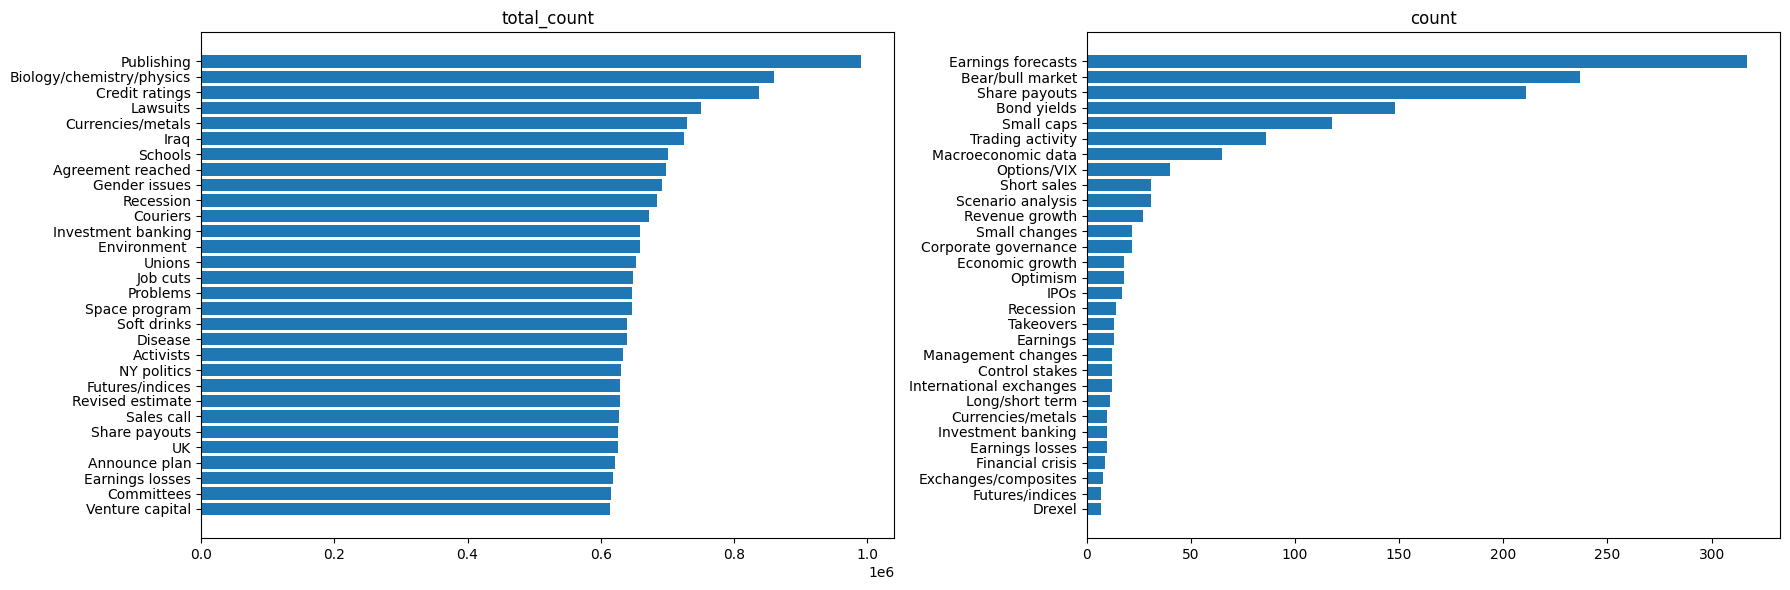

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, col in zip(axes, ["total_count", "count"]):
    top30 = topic_summary.nlargest(30, col)
    ax.barh(top30["topic"], top30[col])
    ax.set_title(col)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

We could try instead of collapsing the lags into one column: For how many stocks is a topic chosen for at least 20 consecutive days. --> focus on actual predicatbility and not artifacts
Still unclear to me how Publishing and natural sciences can end up as the dominant topics.

In [27]:
import re

# 1. Identify lag columns
lag_columns = [col for col in estimation_results.columns if "lag" in col]

# 2. Extract base topic names (remove _lagX suffix)
topics = set(re.sub(r"_lag\d+$", "", col) for col in lag_columns)
# 3. Sum lags within each topic
for topic in topics:
    topic_lag_cols = [col for col in lag_columns if col.startswith(topic + "_lag")]
    estimation_results[topic] = estimation_results[topic_lag_cols].sum(axis=1)
print(estimation_results.columns.tolist())
print(lag_columns)
print(topics)

['Unnamed: 0', 'avg_num_selected_features', 'Lasso_Buffett_lag_1', 'Lasso_Buffett_lag_2', 'Lasso_Buffett_lag_3', 'Lasso_Buffett_lag_4', 'Lasso_Buffett_lag_5', 'Lasso_Buffett_lag_6', 'Lasso_Buffett_lag_7', 'Lasso_Buffett_lag_8', 'Lasso_Buffett_lag_9', 'Lasso_Buffett_lag_10', 'Lasso_Buffett_lag_11', 'Lasso_Buffett_lag_12', 'Lasso_Buffett_lag_13', 'Lasso_Buffett_lag_14', 'Lasso_Buffett_lag_15', 'Lasso_Buffett_lag_16', 'Lasso_Buffett_lag_17', 'Lasso_Buffett_lag_18', 'Lasso_Buffett_lag_19', 'Lasso_Buffett_lag_20', 'Lasso_Buffett_lag_21', 'Lasso_Music_industry_lag_1', 'Lasso_Music_industry_lag_2', 'Lasso_Music_industry_lag_3', 'Lasso_Music_industry_lag_4', 'Lasso_Music_industry_lag_5', 'Lasso_Music_industry_lag_6', 'Lasso_Music_industry_lag_7', 'Lasso_Music_industry_lag_8', 'Lasso_Music_industry_lag_9', 'Lasso_Music_industry_lag_10', 'Lasso_Music_industry_lag_11', 'Lasso_Music_industry_lag_12', 'Lasso_Music_industry_lag_13', 'Lasso_Music_industry_lag_14', 'Lasso_Music_industry_lag_15', 'Lass

In [25]:
estimation_results

,Unnamed: 0,avg_num_selected_features,Lasso_Buffett_lag_1,Lasso_Buffett_lag_2,Lasso_Buffett_lag_3,Lasso_Buffett_lag_4,Lasso_Buffett_lag_5,Lasso_Buffett_lag_6,Lasso_Buffett_lag_7,Lasso_Buffett_lag_8,...,Lasso_Negotiations_lag_12,Lasso_Negotiations_lag_13,Lasso_Negotiations_lag_14,Lasso_Negotiations_lag_15,Lasso_Negotiations_lag_16,Lasso_Negotiations_lag_17,Lasso_Negotiations_lag_18,Lasso_Negotiations_lag_19,Lasso_Negotiations_lag_20,Lasso_Negotiations_lag_21
0,10065,0.273873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10145,5.956233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10294,49.779841,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10375,24.154509,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10516,9.671088,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,93150,17.847480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1616,93153,94.004642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1617,93174,10.792440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1618,93175,86.924403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
